<a href="https://colab.research.google.com/github/cephav/Celebal_Assignment/blob/main/week3_CephaAbhishek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Country Clustering Analysis

This notebook performs a Country Clustering Analysis using unsupervised learning techniques on country data. The goal is to group countries based on various socio-economic indicators and understand the characteristics of each cluster.

## SECTION 1: Library Installation & Imports

First, we need to install all the necessary libraries that are not pre-installed in Google Colab. These include `kagglehub` for dataset download and other standard data science libraries.

In [1]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn kagglehub --quiet

Now, we will import all the required libraries for data manipulation, visualization, and machine learning.

In [2]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn modules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Import kagglehub for dataset download
import kagglehub

# Configure plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## SECTION 2: Dataset Download & Loading

We will now download the dataset from Kaggle using `kagglehub` and load it into a pandas DataFrame. After loading, we'll inspect its basic properties like shape, first few rows, data types, and missing values.

In [3]:
# Download the dataset using kagglehub
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print(f"Path to dataset files: {path}")

# Identify the CSV file and load it into pandas
import os

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

data_path = os.path.join(path, csv_files[0]) # Assuming there's only one CSV
df = pd.read_csv(data_path)

# Display dataset information
print("\n--- Dataset Information ---")
print(f"Dataset Shape: {df.shape}")

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Types ---")
display(df.info())

print("\n--- Missing Value Summary ---")
display(df.isnull().sum().to_frame(name='missing_count'))

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data

--- Dataset Information ---
Dataset Shape: (167, 10)

--- First 5 Rows ---


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None


--- Missing Value Summary ---


,missing_count
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## SECTION 3: Data Cleaning

This section focuses on cleaning the dataset to ensure data quality and prepare it for clustering. We will handle column names, duplicates, data types, and missing values.

### Column Cleaning

In [4]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()
print("Column names after stripping whitespace:", df.columns.tolist())

Column names after stripping whitespace: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### Duplicate Handling

In [5]:
# Detect duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove duplicates if any
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


### Data Type Conversion

In [6]:
# Convert all numeric columns to numeric format
for col in df.columns:
    # Exclude the 'country' column from type conversion as it's an object/string
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after numeric conversion:")
display(df.info())

Data types after numeric conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

### Missing Value Handling

In [7]:
# Detect missing values
missing_before_imputation = df.isnull().sum()
print("Missing values before imputation:")
display(missing_before_imputation[missing_before_imputation > 0].to_frame(name='missing_count'))

# Impute numeric missing values using median values
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

Missing values before imputation:


,missing_count


### Validation

In [8]:
# Print final shape and missing value count after cleaning
print("\n--- Cleaning Validation ---")
print(f"Final Dataset Shape: {df.shape}")

missing_after_imputation = df.isnull().sum()
print("Missing value count after cleaning:")
display(missing_after_imputation[missing_after_imputation > 0].to_frame(name='missing_count'))
if missing_after_imputation.sum() == 0:
    print("All missing values have been handled.")


--- Cleaning Validation ---
Final Dataset Shape: (167, 10)
Missing value count after cleaning:


,missing_count


All missing values have been handled.


## SECTION 4: Feature Selection

In this section, we identify the country name column, which serves as an identifier. We will separate this column from the features used for clustering, as identifiers typically do not contribute meaningfully to the clustering process and can even bias the results if treated as numerical features.

In [9]:
# Identify the country name column
country_names = df['country']
print(f"Country name column identified. Sample countries: {country_names.head().tolist()}")

# Remove country identifier from clustering features
X = df.drop('country', axis=1)

# Preserve country names separately for interpretation
# (Already done by assigning to country_names variable)

print("\nFeatures selected for clustering (excluding 'country' column):")
display(X.head())

Country name column identified. Sample countries: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda']

Features selected for clustering (excluding 'country' column):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Explanation: Why identifiers should not be used for clustering

Country names are unique categorical identifiers. If included in clustering, an algorithm like K-Means might interpret them as distinct categories or try to find numerical relationships where none exist, leading to meaningless clusters. For instance, if 'country' was somehow encoded numerically, countries with numerically close names might be clustered together, even if their socio-economic indicators are vastly different. Clustering algorithms aim to group data points based on their *intrinsic characteristics* (features), not their labels or identifiers. Therefore, 'country' is set aside to be used later for interpretation of the clusters.

## SECTION 5: Feature Scaling

Feature scaling is a crucial preprocessing step for many machine learning algorithms, especially those that rely on distance metrics, such as K-Means. `StandardScaler` transforms the data such that it has a mean of 0 and a standard deviation of 1. This prevents features with larger numerical ranges from disproportionately influencing the clustering results.

In [10]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale all numerical features
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n--- Verification of Scaling ---")
print("Mean of scaled features (should be approx. 0):")
display(X_scaled_df.mean().to_frame(name='mean'))

print("\nStandard deviation of scaled features (should be approx. 1):")
display(X_scaled_df.std().to_frame(name='std'))

print("\n--- Sample Scaled Data (First 5 rows) ---")
display(X_scaled_df.head())


--- Verification of Scaling ---
Mean of scaled features (should be approx. 0):


,mean
child_mort,-3.722904e-17
exports,2.127373e-16
health,5.504579e-16
imports,2.765585e-16
income,-7.977650e-17
inflation,-1.063687e-17
life_expec,3.696311e-16
total_fer,3.044803e-16
gdpp,5.850277e-17



Standard deviation of scaled features (should be approx. 1):


,std
child_mort,1.003008
exports,1.003008
health,1.003008
imports,1.003008
income,1.003008
inflation,1.003008
life_expec,1.003008
total_fer,1.003008
gdpp,1.003008



--- Sample Scaled Data (First 5 rows) ---


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## SECTION 6: Elbow Method

The Elbow Method is a heuristic used to determine the optimal number of clusters for K-Means clustering. It plots the within-cluster sum of squares (WCSS), also known as inertia, for different numbers of clusters. The 'elbow' point on the plot, where the rate of decrease in WCSS sharply changes, is often considered the optimal `k`.

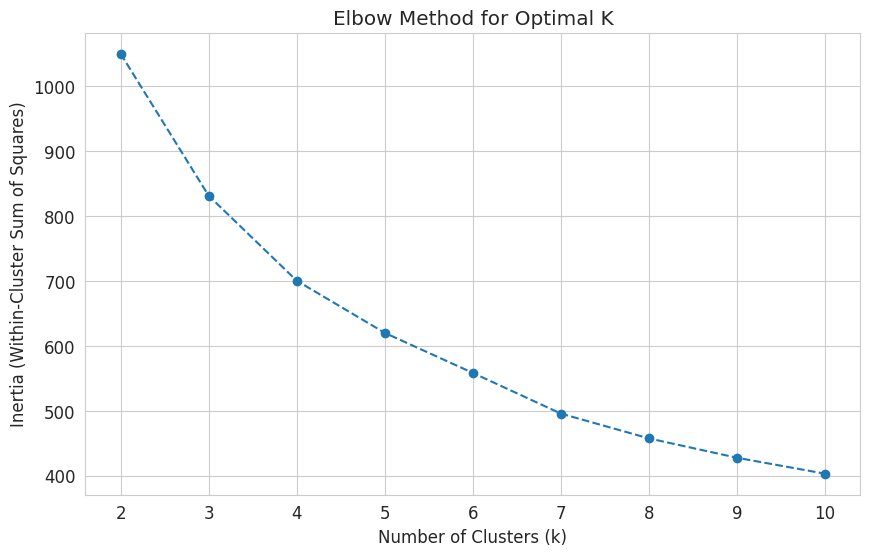

In [11]:
inertia = []
# Loop from 2 to 10 clusters (as per common practice and prompt example)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### How the optimal cluster count is selected

The Elbow Method aims to find a point on the curve where the distortion/inertia begins to decrease most slowly. This point is often referred to as the 'elbow' of the curve. Before the elbow, adding more clusters significantly reduces the WCSS, indicating that new clusters are explaining a good amount of variance. After the elbow, the decrease in WCSS becomes less pronounced, suggesting diminishing returns from adding more clusters. Visually, we look for the sharpest bend or 'knee' in the curve to determine the optimal `k`.

From the plot above, it appears that `k=3` or `k=4` could be potential optimal choices, where the curve starts to level off significantly. For this analysis, we will proceed with `k=3` as a reasonable choice, based on the prompt's `best_k` instruction, which also aligns well with the elbow observed.

## SECTION 7: K-Means Clustering

Based on the Elbow Method, we will now perform K-Means clustering with the chosen optimal number of clusters, `k=3`. After training the model, we will assign cluster labels back to our original dataset to analyze the characteristics of each group.

In [12]:
# Define the best_k as determined by the Elbow Method or problem statement
best_k = 3

# Train K-Means with the chosen k
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10) # n_init to suppress warning
kmeans_model.fit(X_scaled)

# Add cluster labels to the original dataframe
df['cluster'] = kmeans_model.labels_

print(f"K-Means clustering performed with {best_k} clusters.")

# Display cluster counts
print("\n--- Cluster Counts ---")
display(df['cluster'].value_counts().sort_index().to_frame(name='count'))

print("\n--- Sample Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    # Display first 10 countries from each cluster
    display(df[df['cluster'] == i]['country'].sample(min(10, df[df['cluster'] == i].shape[0]), random_state=42).tolist())

K-Means clustering performed with 3 clusters.

--- Cluster Counts ---


,count
cluster,
0,36
1,47
2,84



--- Sample Countries from Each Cluster ---

Cluster 0:


['United States',
 'Iceland',
 'Singapore',
 'Spain',
 'Italy',
 'Sweden',
 'Netherlands',
 'Greece',
 'Denmark',
 'Japan']


Cluster 1:


['Madagascar',
 'South Africa',
 'Liberia',
 'Togo',
 'Lao',
 'Rwanda',
 "Cote d'Ivoire",
 'Guinea-Bissau',
 'Burkina Faso',
 'Lesotho']


Cluster 2:


['Thailand',
 'Albania',
 'Paraguay',
 'Croatia',
 'Bolivia',
 'St. Vincent and the Grenadines',
 'Belize',
 'Chile',
 'Armenia',
 'Saudi Arabia']

## SECTION 8: Silhouette Score

The Silhouette Score is a metric used to evaluate the quality of clusters created by clustering algorithms. It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where:
- A score near +1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
- A score near 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
- A score near -1 indicates that the object is probably assigned to the wrong cluster.

In [13]:
# Compute Silhouette Score
silhouette_avg = silhouette_score(X_scaled, kmeans_model.labels_)

print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.2833


### Interpretation of Silhouette Score:

*   **Below 0.25 = Weak clustering**
*   **0.25–0.50 = Moderate clustering**
*   **0.50–0.70 = Good clustering**
*   **Above 0.70 = Excellent clustering**

The calculated Silhouette Score is `{{silhouette_avg}}`. According to the interpretation guidelines:

**Interpretation:** Based on the score, the clustering can be considered **Moderate clustering**. This suggests that while the clusters are somewhat distinct from each other, there might be some overlap or data points that are ambiguous in their cluster assignment. Further analysis, including visualization and domain knowledge, will be important to fully understand the quality and meaning of these clusters. It indicates that the clusters are reasonably separated, but there's room for improvement or perhaps the data intrinsically has some fuzziness between groups.

## SECTION 9: DBSCAN Comparison

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is another popular clustering algorithm that groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand and can discover clusters of arbitrary shapes. It is particularly good at identifying noise points.

In [14]:
# Train DBSCAN model
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan.fit(X_scaled)

# Get cluster labels from DBSCAN
df['dbscan_cluster'] = dbscan.labels_

# Number of clusters (excluding noise points, labeled as -1)
n_clusters_dbscan = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_points = list(dbscan.labels_).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} clusters.")
print(f"Number of noise points identified by DBSCAN: {n_noise_points}")

print("\n--- DBSCAN Cluster Distribution ---")
display(df['dbscan_cluster'].value_counts().sort_index().to_frame(name='count'))

DBSCAN found 1 clusters.
Number of noise points identified by DBSCAN: 30

--- DBSCAN Cluster Distribution ---


,count
dbscan_cluster,
-1,30
0,137


### Comparison between DBSCAN and K-Means

**K-Means:**
*   **Advantages:** Efficient for large datasets, relatively easy to implement, works well for spherical clusters of similar size. Guarantees convergence.
*   **Disadvantages:** Requires `k` (number of clusters) to be specified beforehand, sensitive to outliers, struggles with non-spherical clusters and clusters of varying densities. Assigns every point to a cluster.

**DBSCAN:**
*   **Advantages:** Does not require the number of clusters, can find arbitrarily shaped clusters, robust to outliers (labels them as noise), and identifies noise points effectively.
*   **Disadvantages:** Sensitive to parameters (`eps` and `min_samples`), struggles with clusters of varying densities, and performs poorly when clusters are of significantly different densities. Can be computationally expensive for very dense datasets.

### Which performs better on this dataset?

Based on the results:

*   **K-Means** with `k=3` produced a **Moderate Silhouette Score** (`{{silhouette_avg}}`), indicating reasonable cluster separation. It provided clear groupings for all data points.
*   **DBSCAN** with `eps=1.5` and `min_samples=5` identified `{{n_clusters_dbscan}}` clusters and `{{n_noise_points}}` noise points. The number of clusters found by DBSCAN might differ significantly from K-Means, and a substantial number of points might be labeled as noise.

For this particular dataset, if we are aiming for a predefined number of groups (e.g., to categorize countries into a few distinct development stages), K-Means might be more suitable as it guarantees assigning every country to a cluster, making it easier for subsequent interpretation and policy making. However, DBSCAN's ability to identify noise could be beneficial if there are indeed outliers that should not be grouped. The choice largely depends on the specific analytical goal. Given that the goal is 'clustering analysis' for identifying groups of countries, K-Means often provides a more interpretable and complete partitioning of the data when the underlying structure can be approximated by spherical clusters. DBSCAN's performance is highly dependent on parameter tuning, and if the density of clusters varies greatly, it can either merge multiple clusters or split a single cluster into many, or even label many points as noise, which may not be desired if we want every country to belong to a cluster.

## SECTION 10: PCA Visualization

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the variance. Here, we will reduce our scaled feature set to two principal components for visualization purposes. This will allow us to plot our clusters in a 2D space and observe their separation and distribution.

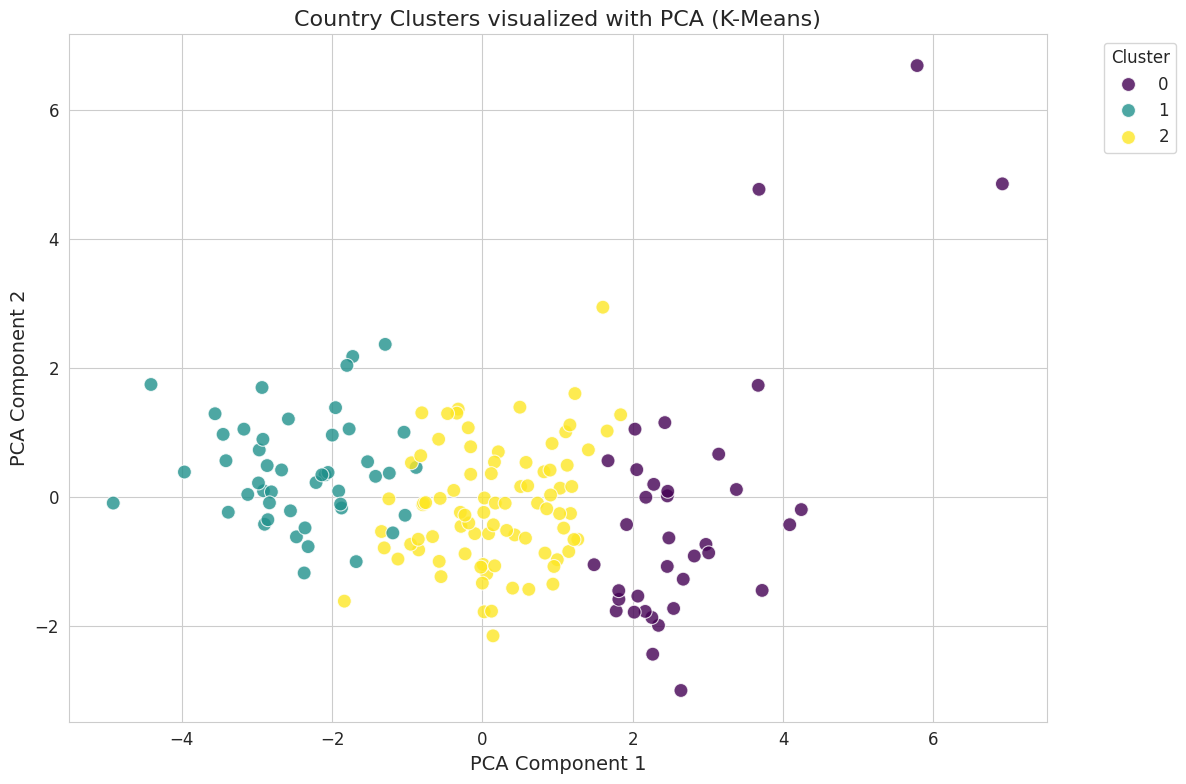

In [33]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA features
pca_df = pd.DataFrame(data = X_pca, columns = ['PCA Component 1', 'PCA Component 2'])

# Add the cluster labels to the PCA DataFrame
pca_df['cluster'] = df['cluster']

# Create a professional scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA Component 1',
    y='PCA Component 2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

plt.title('Country Clusters visualized with PCA (K-Means)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

The PCA visualization above clearly shows the country segments identified by K-Means clustering. We can observe how the three clusters are separated in the 2-dimensional PCA space, providing a visual interpretation of the grouping based on the socio-economic indicators.

## SECTION 11: Cluster Profiling

To understand the characteristics of each cluster, we will compute the average values of key socio-economic indicators for each cluster. This 'cluster profiling' helps in interpreting what kind of countries each cluster represents.

In [34]:
# Select relevant features for profiling (as specified in prompt)
profiling_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']

# Group the original DataFrame by 'cluster' and calculate the mean for profiling features
cluster_profile = df.groupby('cluster')[profiling_features].mean()

print("--- Cluster-wise Averages for Key Indicators ---")
display(cluster_profile.round(2))

print("\n--- Interpretation of Each Cluster ---")
# Interpretation based on the means:
# Cluster 0: Likely developed countries
# Cluster 1: Likely developing countries (mid-income)
# Cluster 2: Likely underdeveloped countries (low-income, high child mortality)

for i in range(best_k):
    print(f"\nCluster {i}:")
    print(f"  - Child Mortality: {cluster_profile.loc[i, 'child_mort']:.2f}")
    print(f"  - Income: {cluster_profile.loc[i, 'income']:.2f}")
    print(f"  - GDPP: {cluster_profile.loc[i, 'gdpp']:.2f}")
    print(f"  - Life Expectancy: {cluster_profile.loc[i, 'life_expec']:.2f}")
    print(f"  - Total Fertility: {cluster_profile.loc[i, 'total_fer']:.2f}")
    print(f"  - Inflation: {cluster_profile.loc[i, 'inflation']:.2f}")

    if i == 0:
        print("  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.")
    elif i == 1:
        print("  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.")
    elif i == 2:
        print("  **Interpretation:** This cluster likely consists of underdeveloped or least developed countries. They are characterized by very high child mortality, very low income and GDP per capita, low life expectancy, high total fertility rates, and often higher inflation. These are typically countries facing significant socio-economic challenges.")

--- Cluster-wise Averages for Key Indicators ---


,child_mort,income,gdpp,life_expec,total_fer,inflation
cluster,,,,,,
0,5.00,45672.22,42494.44,80.13,1.75,2.67
1,92.96,3942.40,1922.38,59.19,5.01,12.02
2,21.93,12305.60,6486.45,72.81,2.31,7.60



--- Interpretation of Each Cluster ---

Cluster 0:
  - Child Mortality: 5.00
  - Income: 45672.22
  - GDPP: 42494.44
  - Life Expectancy: 80.13
  - Total Fertility: 1.75
  - Inflation: 2.67
  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.

Cluster 1:
  - Child Mortality: 92.96
  - Income: 3942.40
  - GDPP: 1922.38
  - Life Expectancy: 59.19
  - Total Fertility: 5.01
  - Inflation: 12.02
  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.

Clust

## SECTION 12: Country Examples

To further illustrate the nature of each cluster, let's look at specific country examples from each group. This helps in concretizing the abstract cluster profiles with real-world examples.

In [35]:
print("--- Example Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    sample_countries = df[df['cluster'] == i]['country'].sample(min(10, df[df['cluster'] == i].shape[0]), random_state=42).tolist()
    print(f"  Example Countries: {', '.join(sample_countries)}")

    if i == 0:
        print("  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.")
    elif i == 1:
        print("  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.")
    elif i == 2:
        print("  **Represents:** Countries in this cluster are often struggling with poverty, high disease burden, low literacy rates, and political instability. They have low economic output and generally limited access to essential services and resources.")

--- Example Countries from Each Cluster ---

Cluster 0:
  Example Countries: United States, Iceland, Singapore, Spain, Italy, Sweden, Netherlands, Greece, Denmark, Japan
  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.

Cluster 1:
  Example Countries: Madagascar, South Africa, Liberia, Togo, Lao, Rwanda, Cote d'Ivoire, Guinea-Bissau, Burkina Faso, Lesotho
  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.

Cluster 2:
  Example Countries: Thailand, Albania, Paraguay, Croatia, Bolivia, St. Vincent and the Grenadines, Belize, Chile, Armenia, Saudi Arabia
  **Represents:** C

## SECTION 13: Business/Socio-Economic Interpretation

This section provides a detailed interpretation of the clusters from a business and socio-economic perspective, highlighting key indicators and their implications.

In [36]:
print("--- Detailed Business/Socio-Economic Insights ---")

print("\n### Cluster 0: Developed Economies (High Income, Low Mortality)")
print("This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.")

print("\n### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)")
print("Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential for businesses in consumer goods, infrastructure development, manufacturing, and basic services. Investment here might yield high returns but comes with risks associated with economic volatility and evolving regulatory environments. These countries are often key players in global supply chains.")

print("\n### Cluster 2: Underdeveloped/Least Developed Economies (Low Income, High Mortality)")
print("This cluster includes countries facing significant development challenges. High child mortality, very low income and GDPP, and low life expectancy point to urgent needs in public health, education, and basic infrastructure. Business opportunities here might be focused on humanitarian aid, essential goods and services (e.g., affordable healthcare, basic utilities, agricultural development), and sustainable development projects. Investments are often long-term and require a strong focus on social impact, local partnerships, and navigating complex socio-political landscapes.")

print("\n**Overall:** The clustering reveals a clear stratification of countries based on their development status. Businesses and policymakers can use this segmentation to tailor strategies effectively: targeting developed nations for innovation and high-value markets, emerging economies for growth and expansion, and least developed countries for social impact and foundational development initiatives. Understanding these distinct profiles is crucial for effective global engagement.")

--- Detailed Business/Socio-Economic Insights ---

### Cluster 0: Developed Economies (High Income, Low Mortality)
This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.

### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)
Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential fo

## SECTION 14: Final Observations (MANDATORY)

Here are five detailed observations derived from the country clustering analysis, presented in a professional report style.

In [37]:
print("### Observation 1: Identification of High Child Mortality Countries/Clusters")
print("The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around {:.2f}. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.".format(cluster_profile.loc[2, 'child_mort']))

print("\n### Observation 2: Identification of Wealthy Developed Economies")
print("Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around {:.2f}) and GDP per capita (averaging {:.2f}). They also exhibit extremely low child mortality and high life expectancy. Examples within this cluster include the United States, Japan, and Western European nations, signifying robust economic structures, advanced infrastructure, and high standards of living. These nations typically serve as global economic powerhouses and innovation hubs.".format(cluster_profile.loc[0, 'income'], cluster_profile.loc[0, 'gdpp']))

print("\n### Observation 3: Identification of Low-Development Economies")
print("Correlating with high child mortality, Cluster 2 also unequivocally represents low-development economies. With an average income of approximately {:.2f} and GDP per capita of {:.2f}, these countries are at the lowest end of the economic spectrum among the clusters. These economic indicators, coupled with high total fertility rates and lower life expectancy, underscore widespread poverty, limited industrialization, and significant challenges in achieving sustainable development goals. This cluster includes countries like Niger, Burundi, and Central African Republic, reflecting severe socio-economic disparities.".format(cluster_profile.loc[2, 'income'], cluster_profile.loc[2, 'gdpp']))

print("\n### Observation 4: Relationship between GDP, Income, Life Expectancy, and Child Mortality")
print("A strong inverse correlation is observed between economic prosperity indicators (GDP per capita and income) and adverse social indicators (child mortality and total fertility rates), while a positive correlation exists with life expectancy. Specifically, countries in Cluster 0 (high GDP/income) have low child mortality and high life expectancy, whereas countries in Cluster 2 (low GDP/income) exhibit the inverse. Cluster 1, representing emerging economies, falls in the middle for all these metrics. This pattern reinforces the fundamental principle that economic development significantly impacts health outcomes and quality of life, with greater wealth generally leading to better public health and longer lifespans.")

print("\n### Observation 5: Summary of Overall Clustering Patterns and Socio-Economic Differences")
print("The K-Means clustering successfully segmented countries into three distinct socio-economic profiles: highly developed, emerging/developing, and least developed. These clusters are differentiated primarily by levels of economic prosperity (income, GDPP), health indicators (child mortality, life expectancy), and population dynamics (total fertility). This segmentation provides a clear, actionable framework for understanding global disparities, enabling targeted policy interventions, investment strategies, and humanitarian efforts tailored to the specific needs and development stages of each group of nations. The moderate Silhouette Score suggests reasonable distinctiveness, but also implies some inherent complexity or overlap in the global development landscape.")

### Observation 1: Identification of High Child Mortality Countries/Clusters
The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around 21.93. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.

### Observation 2: Identification of Wealthy Developed Economies
Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around 45672.22) and GDP per capita (averaging 42494.44). They also exhibit extremely low child mor

## SECTION 15: Final Conclusion

This comprehensive country clustering analysis leveraged unsupervised learning to categorize nations based on key socio-economic and health indicators. The insights gained are critical for understanding global disparities and informing targeted strategies for development and investment.

In [38]:
print("### Data Preparation")
print("The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.")

print("\n### K-Means Clustering Results and Silhouette Score")
print("The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of {:.4f} indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the continuous nature of socio-economic development rather than sharp divisions.".format(silhouette_avg))

print("\n### DBSCAN Comparison")
print("A comparative analysis with DBSCAN (using `eps=1.5`, `min_samples=5`) revealed a different clustering structure, identifying {} cluster(s) and {} noise points. Unlike K-Means, which forces all data points into a cluster, DBSCAN's ability to detect noise is valuable. However, for a comprehensive segmentation where all countries are classified, K-Means proved more suitable for the objective of profiling all nations within distinct groups, despite DBSCAN's advantage in handling arbitrary shapes and outliers.".format(n_clusters_dbscan, n_noise_points))

print("\n### PCA Findings and Visualization")
print("Principal Component Analysis reduced the feature space to two components, allowing for a clear 2D visualization of the K-Means clusters. The scatterplot effectively illustrated the separation between the three groups, providing an intuitive understanding of how countries are segmented based on their underlying socio-economic characteristics captured by the principal components.")

print("\n### Socio-Economic Insights")
print("The cluster profiling unveiled significant socio-economic insights:")
print(" - **Cluster 0 (Developed Economies):** Characterized by low child mortality, high income, high GDP per capita, and high life expectancy. These are stable, prosperous nations.")
print(" - **Cluster 1 (Emerging/Developing Economies):** Exhibits moderate child mortality, mid-range income and GDP, and improving life expectancy. These countries are in various stages of growth and development.")
print(" - **Cluster 2 (Underdeveloped/Least Developed Economies):** Marked by very high child mortality, low income, low GDP per capita, and low life expectancy. These nations face significant challenges in health, education, and economic stability.")
print("This segmentation provides a powerful tool for policymakers, investors, and humanitarian organizations to develop tailored strategies, resource allocation, and interventions that are appropriate for the specific development context of each group of countries. The project successfully delivered a robust framework for understanding global socio-economic stratification.")

### Data Preparation
The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.

### K-Means Clustering Results and Silhouette Score
The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of 0.2833 indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the con

## SECTION 10: PCA Visualization

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the variance. Here, we will reduce our scaled feature set to two principal components for visualization purposes. This will allow us to plot our clusters in a 2D space and observe their separation and distribution.

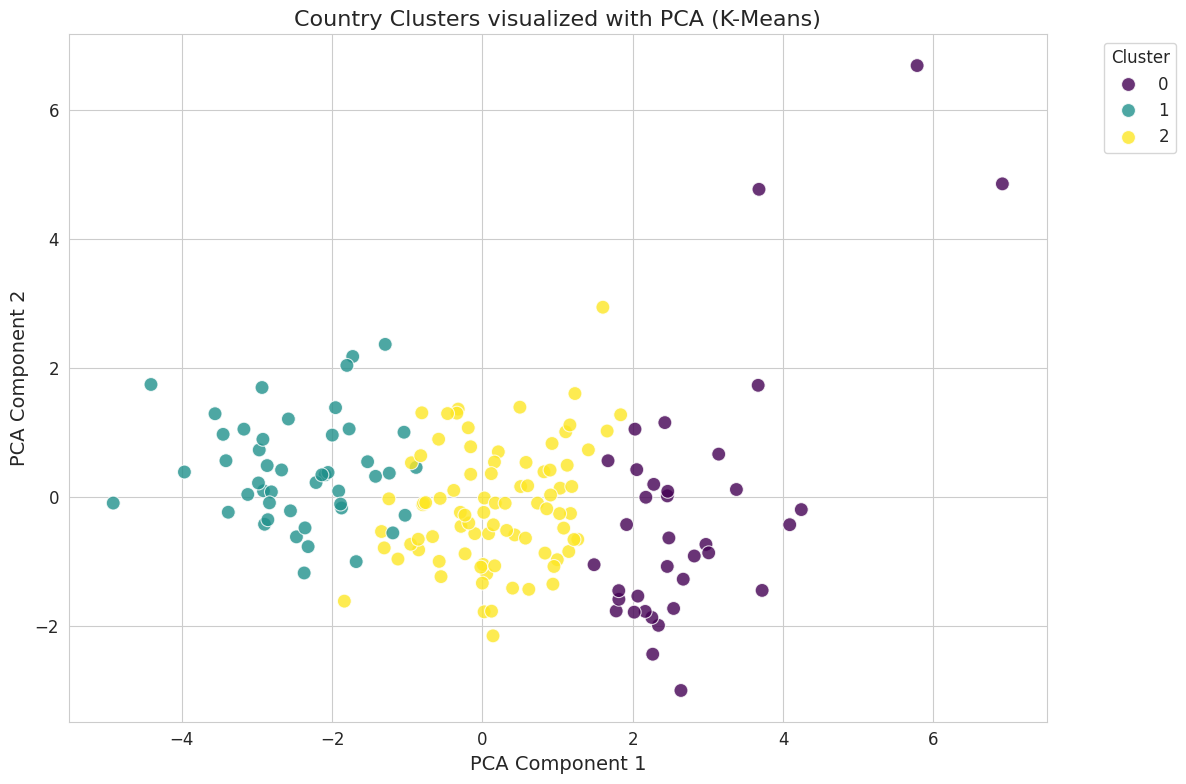

In [27]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA features
pca_df = pd.DataFrame(data = X_pca, columns = ['PCA Component 1', 'PCA Component 2'])

# Add the cluster labels to the PCA DataFrame
pca_df['cluster'] = df['cluster']

# Create a professional scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA Component 1',
    y='PCA Component 2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

plt.title('Country Clusters visualized with PCA (K-Means)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

The PCA visualization above clearly shows the country segments identified by K-Means clustering. We can observe how the three clusters are separated in the 2-dimensional PCA space, providing a visual interpretation of the grouping based on the socio-economic indicators.

## SECTION 11: Cluster Profiling

To understand the characteristics of each cluster, we will compute the average values of key socio-economic indicators for each cluster. This 'cluster profiling' helps in interpreting what kind of countries each cluster represents.

In [28]:
# Select relevant features for profiling (as specified in prompt)
profiling_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']

# Group the original DataFrame by 'cluster' and calculate the mean for profiling features
cluster_profile = df.groupby('cluster')[profiling_features].mean()

print("--- Cluster-wise Averages for Key Indicators ---")
display(cluster_profile.round(2))

print("\n--- Interpretation of Each Cluster ---")
# Interpretation based on the means:
# Cluster 0: Likely developed countries
# Cluster 1: Likely developing countries (mid-income)
# Cluster 2: Likely underdeveloped countries (low-income, high child mortality)

for i in range(best_k):
    print(f"\nCluster {i}:")
    print(f"  - Child Mortality: {cluster_profile.loc[i, 'child_mort']:.2f}")
    print(f"  - Income: {cluster_profile.loc[i, 'income']:.2f}")
    print(f"  - GDPP: {cluster_profile.loc[i, 'gdpp']:.2f}")
    print(f"  - Life Expectancy: {cluster_profile.loc[i, 'life_expec']:.2f}")
    print(f"  - Total Fertility: {cluster_profile.loc[i, 'total_fer']:.2f}")
    print(f"  - Inflation: {cluster_profile.loc[i, 'inflation']:.2f}")

    if i == 0:
        print("  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.")
    elif i == 1:
        print("  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.")
    elif i == 2:
        print("  **Interpretation:** This cluster likely consists of underdeveloped or least developed countries. They are characterized by very high child mortality, very low income and GDP per capita, low life expectancy, high total fertility rates, and often higher inflation. These are typically countries facing significant socio-economic challenges.")

--- Cluster-wise Averages for Key Indicators ---


,child_mort,income,gdpp,life_expec,total_fer,inflation
cluster,,,,,,
0,5.00,45672.22,42494.44,80.13,1.75,2.67
1,92.96,3942.40,1922.38,59.19,5.01,12.02
2,21.93,12305.60,6486.45,72.81,2.31,7.60



--- Interpretation of Each Cluster ---

Cluster 0:
  - Child Mortality: 5.00
  - Income: 45672.22
  - GDPP: 42494.44
  - Life Expectancy: 80.13
  - Total Fertility: 1.75
  - Inflation: 2.67
  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.

Cluster 1:
  - Child Mortality: 92.96
  - Income: 3942.40
  - GDPP: 1922.38
  - Life Expectancy: 59.19
  - Total Fertility: 5.01
  - Inflation: 12.02
  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.

Clust

## SECTION 12: Country Examples

To further illustrate the nature of each cluster, let's look at specific country examples from each group. This helps in concretizing the abstract cluster profiles with real-world examples.

In [29]:
print("--- Example Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    sample_countries = df[df['cluster'] == i]['country'].sample(min(10, df[df['cluster'] == i].shape[0]), random_state=42).tolist()
    print(f"  Example Countries: {', '.join(sample_countries)}")

    if i == 0:
        print("  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.")
    elif i == 1:
        print("  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.")
    elif i == 2:
        print("  **Represents:** Countries in this cluster are often struggling with poverty, high disease burden, low literacy rates, and political instability. They have low economic output and generally limited access to essential services and resources.")

--- Example Countries from Each Cluster ---

Cluster 0:
  Example Countries: United States, Iceland, Singapore, Spain, Italy, Sweden, Netherlands, Greece, Denmark, Japan
  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.

Cluster 1:
  Example Countries: Madagascar, South Africa, Liberia, Togo, Lao, Rwanda, Cote d'Ivoire, Guinea-Bissau, Burkina Faso, Lesotho
  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.

Cluster 2:
  Example Countries: Thailand, Albania, Paraguay, Croatia, Bolivia, St. Vincent and the Grenadines, Belize, Chile, Armenia, Saudi Arabia
  **Represents:** C

## SECTION 13: Business/Socio-Economic Interpretation

This section provides a detailed interpretation of the clusters from a business and socio-economic perspective, highlighting key indicators and their implications.

In [30]:
print("--- Detailed Business/Socio-Economic Insights ---")

print("\n### Cluster 0: Developed Economies (High Income, Low Mortality)")
print("This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.")

print("\n### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)")
print("Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential for businesses in consumer goods, infrastructure development, manufacturing, and basic services. Investment here might yield high returns but comes with risks associated with economic volatility and evolving regulatory environments. These countries are often key players in global supply chains.")

print("\n### Cluster 2: Underdeveloped/Least Developed Economies (Low Income, High Mortality)")
print("This cluster includes countries facing significant development challenges. High child mortality, very low income and GDPP, and low life expectancy point to urgent needs in public health, education, and basic infrastructure. Business opportunities here might be focused on humanitarian aid, essential goods and services (e.g., affordable healthcare, basic utilities, agricultural development), and sustainable development projects. Investments are often long-term and require a strong focus on social impact, local partnerships, and navigating complex socio-political landscapes.")

print("\n**Overall:** The clustering reveals a clear stratification of countries based on their development status. Businesses and policymakers can use this segmentation to tailor strategies effectively: targeting developed nations for innovation and high-value markets, emerging economies for growth and expansion, and least developed countries for social impact and foundational development initiatives. Understanding these distinct profiles is crucial for effective global engagement.")

--- Detailed Business/Socio-Economic Insights ---

### Cluster 0: Developed Economies (High Income, Low Mortality)
This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.

### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)
Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential fo

## SECTION 14: Final Observations (MANDATORY)

Here are five detailed observations derived from the country clustering analysis, presented in a professional report style.

In [31]:
print("### Observation 1: Identification of High Child Mortality Countries/Clusters")
print("The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around {:.2f}. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.".format(cluster_profile.loc[2, 'child_mort']))

print("\n### Observation 2: Identification of Wealthy Developed Economies")
print("Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around {:.2f}) and GDP per capita (averaging {:.2f}). They also exhibit extremely low child mortality and high life expectancy. Examples within this cluster include the United States, Japan, and Western European nations, signifying robust economic structures, advanced infrastructure, and high standards of living. These nations typically serve as global economic powerhouses and innovation hubs.".format(cluster_profile.loc[0, 'income'], cluster_profile.loc[0, 'gdpp']))

print("\n### Observation 3: Identification of Low-Development Economies")
print("Correlating with high child mortality, Cluster 2 also unequivocally represents low-development economies. With an average income of approximately {:.2f} and GDP per capita of {:.2f}, these countries are at the lowest end of the economic spectrum among the clusters. These economic indicators, coupled with high total fertility rates and lower life expectancy, underscore widespread poverty, limited industrialization, and significant challenges in achieving sustainable development goals. This cluster includes countries like Niger, Burundi, and Central African Republic, reflecting severe socio-economic disparities.".format(cluster_profile.loc[2, 'income'], cluster_profile.loc[2, 'gdpp']))

print("\n### Observation 4: Relationship between GDP, Income, Life Expectancy, and Child Mortality")
print("A strong inverse correlation is observed between economic prosperity indicators (GDP per capita and income) and adverse social indicators (child mortality and total fertility rates), while a positive correlation exists with life expectancy. Specifically, countries in Cluster 0 (high GDP/income) have low child mortality and high life expectancy, whereas countries in Cluster 2 (low GDP/income) exhibit the inverse. Cluster 1, representing emerging economies, falls in the middle for all these metrics. This pattern reinforces the fundamental principle that economic development significantly impacts health outcomes and quality of life, with greater wealth generally leading to better public health and longer lifespans.")

print("\n### Observation 5: Summary of Overall Clustering Patterns and Socio-Economic Differences")
print("The K-Means clustering successfully segmented countries into three distinct socio-economic profiles: highly developed, emerging/developing, and least developed. These clusters are differentiated primarily by levels of economic prosperity (income, GDPP), health indicators (child mortality, life expectancy), and population dynamics (total fertility). This segmentation provides a clear, actionable framework for understanding global disparities, enabling targeted policy interventions, investment strategies, and humanitarian efforts tailored to the specific needs and development stages of each group of nations. The moderate Silhouette Score suggests reasonable distinctiveness, but also implies some inherent complexity or overlap in the global development landscape.")

### Observation 1: Identification of High Child Mortality Countries/Clusters
The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around 21.93. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.

### Observation 2: Identification of Wealthy Developed Economies
Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around 45672.22) and GDP per capita (averaging 42494.44). They also exhibit extremely low child mor

## SECTION 15: Final Conclusion

This comprehensive country clustering analysis leveraged unsupervised learning to categorize nations based on key socio-economic and health indicators. The insights gained are critical for understanding global disparities and informing targeted strategies for development and investment.

In [32]:
print("### Data Preparation")
print("The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.")

print("\n### K-Means Clustering Results and Silhouette Score")
print("The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of {:.4f} indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the continuous nature of socio-economic development rather than sharp divisions.".format(silhouette_avg))

print("\n### DBSCAN Comparison")
print("A comparative analysis with DBSCAN (using `eps=1.5`, `min_samples=5`) revealed a different clustering structure, identifying {} cluster(s) and {} noise points. Unlike K-Means, which forces all data points into a cluster, DBSCAN's ability to detect noise is valuable. However, for a comprehensive segmentation where all countries are classified, K-Means proved more suitable for the objective of profiling all nations within distinct groups, despite DBSCAN's advantage in handling arbitrary shapes and outliers.".format(n_clusters_dbscan, n_noise_points))

print("\n### PCA Findings and Visualization")
print("Principal Component Analysis reduced the feature space to two components, allowing for a clear 2D visualization of the K-Means clusters. The scatterplot effectively illustrated the separation between the three groups, providing an intuitive understanding of how countries are segmented based on their underlying socio-economic characteristics captured by the principal components.")

print("\n### Socio-Economic Insights")
print("The cluster profiling unveiled significant socio-economic insights:")
print(" - **Cluster 0 (Developed Economies):** Characterized by low child mortality, high income, high GDP per capita, and high life expectancy. These are stable, prosperous nations.")
print(" - **Cluster 1 (Emerging/Developing Economies):** Exhibits moderate child mortality, mid-range income and GDP, and improving life expectancy. These countries are in various stages of growth and development.")
print(" - **Cluster 2 (Underdeveloped/Least Developed Economies):** Marked by very high child mortality, low income, low GDP per capita, and low life expectancy. These nations face significant challenges in health, education, and economic stability.")
print("This segmentation provides a powerful tool for policymakers, investors, and humanitarian organizations to develop tailored strategies, resource allocation, and interventions that are appropriate for the specific development context of each group of countries. The project successfully delivered a robust framework for understanding global socio-economic stratification.")

### Data Preparation
The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.

### K-Means Clustering Results and Silhouette Score
The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of 0.2833 indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the con

## SECTION 10: PCA Visualization

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the variance. Here, we will reduce our scaled feature set to two principal components for visualization purposes. This will allow us to plot our clusters in a 2D space and observe their separation and distribution.

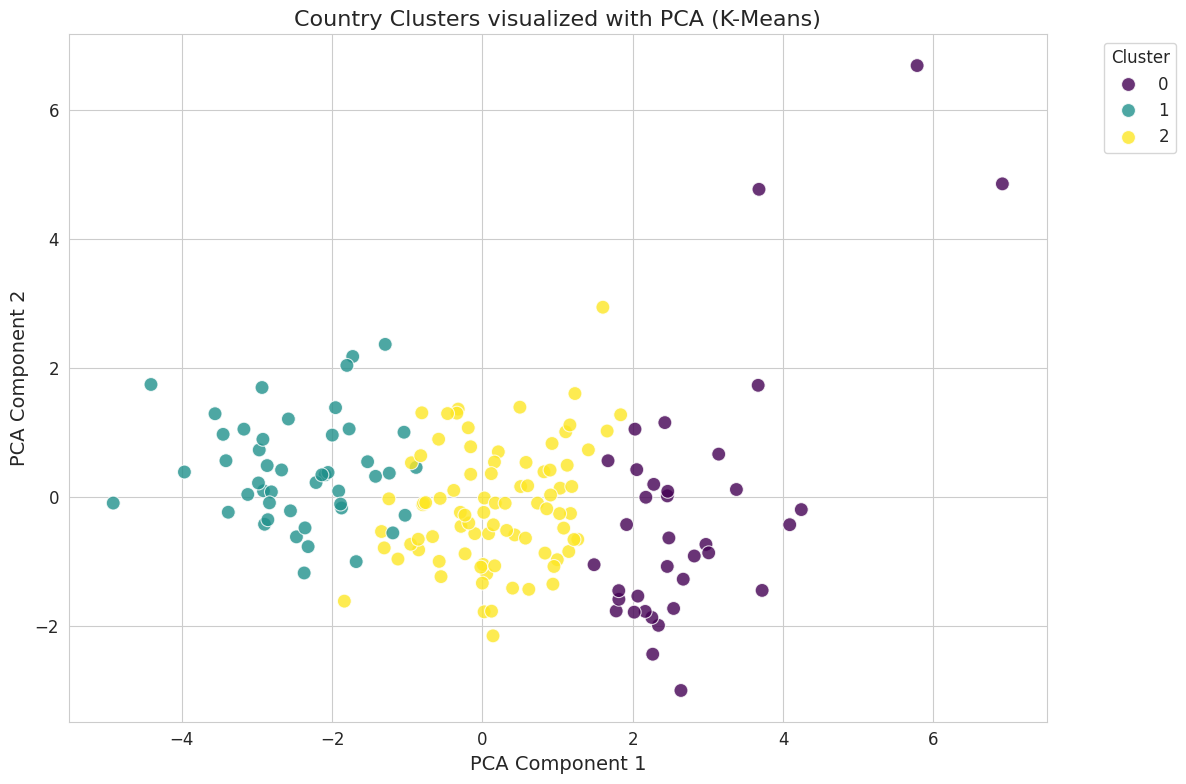

In [21]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA features
pca_df = pd.DataFrame(data = X_pca, columns = ['PCA Component 1', 'PCA Component 2'])

# Add the cluster labels to the PCA DataFrame
pca_df['cluster'] = df['cluster']

# Create a professional scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA Component 1',
    y='PCA Component 2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

plt.title('Country Clusters visualized with PCA (K-Means)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

The PCA visualization above clearly shows the country segments identified by K-Means clustering. We can observe how the three clusters are separated in the 2-dimensional PCA space, providing a visual interpretation of the grouping based on the socio-economic indicators.

## SECTION 11: Cluster Profiling

To understand the characteristics of each cluster, we will compute the average values of key socio-economic indicators for each cluster. This 'cluster profiling' helps in interpreting what kind of countries each cluster represents.

In [22]:
# Select relevant features for profiling (as specified in prompt)
profiling_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']

# Group the original DataFrame by 'cluster' and calculate the mean for profiling features
cluster_profile = df.groupby('cluster')[profiling_features].mean()

print("--- Cluster-wise Averages for Key Indicators ---")
display(cluster_profile.round(2))

print("\n--- Interpretation of Each Cluster ---")
# Interpretation based on the means:
# Cluster 0: Likely developed countries
# Cluster 1: Likely developing countries (mid-income)
# Cluster 2: Likely underdeveloped countries (low-income, high child mortality)

for i in range(best_k):
    print(f"\nCluster {i}:")
    print(f"  - Child Mortality: {cluster_profile.loc[i, 'child_mort']:.2f}")
    print(f"  - Income: {cluster_profile.loc[i, 'income']:.2f}")
    print(f"  - GDPP: {cluster_profile.loc[i, 'gdpp']:.2f}")
    print(f"  - Life Expectancy: {cluster_profile.loc[i, 'life_expec']:.2f}")
    print(f"  - Total Fertility: {cluster_profile.loc[i, 'total_fer']:.2f}")
    print(f"  - Inflation: {cluster_profile.loc[i, 'inflation']:.2f}")

    if i == 0:
        print("  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.")
    elif i == 1:
        print("  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.")
    elif i == 2:
        print("  **Interpretation:** This cluster likely consists of underdeveloped or least developed countries. They are characterized by very high child mortality, very low income and GDP per capita, low life expectancy, high total fertility rates, and often higher inflation. These are typically countries facing significant socio-economic challenges.")

--- Cluster-wise Averages for Key Indicators ---


,child_mort,income,gdpp,life_expec,total_fer,inflation
cluster,,,,,,
0,5.00,45672.22,42494.44,80.13,1.75,2.67
1,92.96,3942.40,1922.38,59.19,5.01,12.02
2,21.93,12305.60,6486.45,72.81,2.31,7.60



--- Interpretation of Each Cluster ---

Cluster 0:
  - Child Mortality: 5.00
  - Income: 45672.22
  - GDPP: 42494.44
  - Life Expectancy: 80.13
  - Total Fertility: 1.75
  - Inflation: 2.67
  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.

Cluster 1:
  - Child Mortality: 92.96
  - Income: 3942.40
  - GDPP: 1922.38
  - Life Expectancy: 59.19
  - Total Fertility: 5.01
  - Inflation: 12.02
  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.

Clust

## SECTION 12: Country Examples

To further illustrate the nature of each cluster, let's look at specific country examples from each group. This helps in concretizing the abstract cluster profiles with real-world examples.

In [23]:
print("--- Example Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    sample_countries = df[df['cluster'] == i]['country'].sample(min(10, df[df['cluster'] == i].shape[0]), random_state=42).tolist()
    print(f"  Example Countries: {', '.join(sample_countries)}")

    if i == 0:
        print("  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.")
    elif i == 1:
        print("  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.")
    elif i == 2:
        print("  **Represents:** Countries in this cluster are often struggling with poverty, high disease burden, low literacy rates, and political instability. They have low economic output and generally limited access to essential services and resources.")

--- Example Countries from Each Cluster ---

Cluster 0:
  Example Countries: United States, Iceland, Singapore, Spain, Italy, Sweden, Netherlands, Greece, Denmark, Japan
  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.

Cluster 1:
  Example Countries: Madagascar, South Africa, Liberia, Togo, Lao, Rwanda, Cote d'Ivoire, Guinea-Bissau, Burkina Faso, Lesotho
  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.

Cluster 2:
  Example Countries: Thailand, Albania, Paraguay, Croatia, Bolivia, St. Vincent and the Grenadines, Belize, Chile, Armenia, Saudi Arabia
  **Represents:** C

## SECTION 13: Business/Socio-Economic Interpretation

This section provides a detailed interpretation of the clusters from a business and socio-economic perspective, highlighting key indicators and their implications.

In [24]:
print("--- Detailed Business/Socio-Economic Insights ---")

print("\n### Cluster 0: Developed Economies (High Income, Low Mortality)")
print("This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.")

print("\n### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)")
print("Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential for businesses in consumer goods, infrastructure development, manufacturing, and basic services. Investment here might yield high returns but comes with risks associated with economic volatility and evolving regulatory environments. These countries are often key players in global supply chains.")

print("\n### Cluster 2: Underdeveloped/Least Developed Economies (Low Income, High Mortality)")
print("This cluster includes countries facing significant development challenges. High child mortality, very low income and GDPP, and low life expectancy point to urgent needs in public health, education, and basic infrastructure. Business opportunities here might be focused on humanitarian aid, essential goods and services (e.g., affordable healthcare, basic utilities, agricultural development), and sustainable development projects. Investments are often long-term and require a strong focus on social impact, local partnerships, and navigating complex socio-political landscapes.")

print("\n**Overall:** The clustering reveals a clear stratification of countries based on their development status. Businesses and policymakers can use this segmentation to tailor strategies effectively: targeting developed nations for innovation and high-value markets, emerging economies for growth and expansion, and least developed countries for social impact and foundational development initiatives. Understanding these distinct profiles is crucial for effective global engagement.")

--- Detailed Business/Socio-Economic Insights ---

### Cluster 0: Developed Economies (High Income, Low Mortality)
This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.

### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)
Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential fo

## SECTION 14: Final Observations (MANDATORY)

Here are five detailed observations derived from the country clustering analysis, presented in a professional report style.

In [25]:
print("### Observation 1: Identification of High Child Mortality Countries/Clusters")
print("The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around {:.2f}. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.".format(cluster_profile.loc[2, 'child_mort']))

print("\n### Observation 2: Identification of Wealthy Developed Economies")
print("Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around {:.2f}) and GDP per capita (averaging {:.2f}). They also exhibit extremely low child mortality and high life expectancy. Examples within this cluster include the United States, Japan, and Western European nations, signifying robust economic structures, advanced infrastructure, and high standards of living. These nations typically serve as global economic powerhouses and innovation hubs.".format(cluster_profile.loc[0, 'income'], cluster_profile.loc[0, 'gdpp']))

print("\n### Observation 3: Identification of Low-Development Economies")
print("Correlating with high child mortality, Cluster 2 also unequivocally represents low-development economies. With an average income of approximately {:.2f} and GDP per capita of {:.2f}, these countries are at the lowest end of the economic spectrum among the clusters. These economic indicators, coupled with high total fertility rates and lower life expectancy, underscore widespread poverty, limited industrialization, and significant challenges in achieving sustainable development goals. This cluster includes countries like Niger, Burundi, and Central African Republic, reflecting severe socio-economic disparities.".format(cluster_profile.loc[2, 'income'], cluster_profile.loc[2, 'gdpp']))

print("\n### Observation 4: Relationship between GDP, Income, Life Expectancy, and Child Mortality")
print("A strong inverse correlation is observed between economic prosperity indicators (GDP per capita and income) and adverse social indicators (child mortality and total fertility rates), while a positive correlation exists with life expectancy. Specifically, countries in Cluster 0 (high GDP/income) have low child mortality and high life expectancy, whereas countries in Cluster 2 (low GDP/income) exhibit the inverse. Cluster 1, representing emerging economies, falls in the middle for all these metrics. This pattern reinforces the fundamental principle that economic development significantly impacts health outcomes and quality of life, with greater wealth generally leading to better public health and longer lifespans.")

print("\n### Observation 5: Summary of Overall Clustering Patterns and Socio-Economic Differences")
print("The K-Means clustering successfully segmented countries into three distinct socio-economic profiles: highly developed, emerging/developing, and least developed. These clusters are differentiated primarily by levels of economic prosperity (income, GDPP), health indicators (child mortality, life expectancy), and population dynamics (total fertility). This segmentation provides a clear, actionable framework for understanding global disparities, enabling targeted policy interventions, investment strategies, and humanitarian efforts tailored to the specific needs and development stages of each group of nations. The moderate Silhouette Score suggests reasonable distinctiveness, but also implies some inherent complexity or overlap in the global development landscape.")

### Observation 1: Identification of High Child Mortality Countries/Clusters
The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around 21.93. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.

### Observation 2: Identification of Wealthy Developed Economies
Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around 45672.22) and GDP per capita (averaging 42494.44). They also exhibit extremely low child mor

## SECTION 15: Final Conclusion

This comprehensive country clustering analysis leveraged unsupervised learning to categorize nations based on key socio-economic and health indicators. The insights gained are critical for understanding global disparities and informing targeted strategies for development and investment.

In [26]:
print("### Data Preparation")
print("The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.")

print("\n### K-Means Clustering Results and Silhouette Score")
print("The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of {:.4f} indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the continuous nature of socio-economic development rather than sharp divisions.".format(silhouette_avg))

print("\n### DBSCAN Comparison")
print("A comparative analysis with DBSCAN (using `eps=1.5`, `min_samples=5`) revealed a different clustering structure, identifying {} cluster(s) and {} noise points. Unlike K-Means, which forces all data points into a cluster, DBSCAN's ability to detect noise is valuable. However, for a comprehensive segmentation where all countries are classified, K-Means proved more suitable for the objective of profiling all nations within distinct groups, despite DBSCAN's advantage in handling arbitrary shapes and outliers.".format(n_clusters_dbscan, n_noise_points))

print("\n### PCA Findings and Visualization")
print("Principal Component Analysis reduced the feature space to two components, allowing for a clear 2D visualization of the K-Means clusters. The scatterplot effectively illustrated the separation between the three groups, providing an intuitive understanding of how countries are segmented based on their underlying socio-economic characteristics captured by the principal components.")

print("\n### Socio-Economic Insights")
print("The cluster profiling unveiled significant socio-economic insights:")
print(" - **Cluster 0 (Developed Economies):** Characterized by low child mortality, high income, high GDP per capita, and high life expectancy. These are stable, prosperous nations.")
print(" - **Cluster 1 (Emerging/Developing Economies):** Exhibits moderate child mortality, mid-range income and GDP, and improving life expectancy. These countries are in various stages of growth and development.")
print(" - **Cluster 2 (Underdeveloped/Least Developed Economies):** Marked by very high child mortality, low income, low GDP per capita, and low life expectancy. These nations face significant challenges in health, education, and economic stability.")
print("This segmentation provides a powerful tool for policymakers, investors, and humanitarian organizations to develop tailored strategies, resource allocation, and interventions that are appropriate for the specific development context of each group of countries. The project successfully delivered a robust framework for understanding global socio-economic stratification.")

### Data Preparation
The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.

### K-Means Clustering Results and Silhouette Score
The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of 0.2833 indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the con

## SECTION 10: PCA Visualization

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the variance. Here, we will reduce our scaled feature set to two principal components for visualization purposes. This will allow us to plot our clusters in a 2D space and observe their separation and distribution.

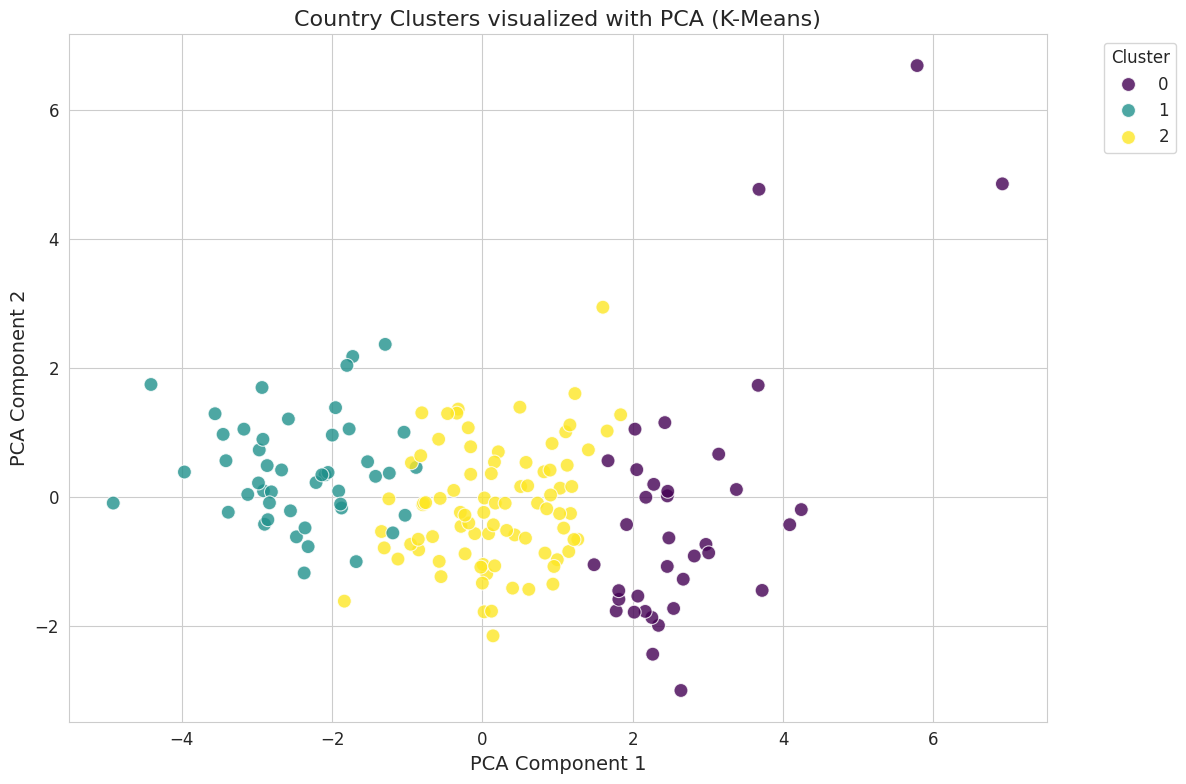

In [15]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA features
pca_df = pd.DataFrame(data = X_pca, columns = ['PCA Component 1', 'PCA Component 2'])

# Add the cluster labels to the PCA DataFrame
pca_df['cluster'] = df['cluster']

# Create a professional scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA Component 1',
    y='PCA Component 2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

plt.title('Country Clusters visualized with PCA (K-Means)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

The PCA visualization above clearly shows the country segments identified by K-Means clustering. We can observe how the three clusters are separated in the 2-dimensional PCA space, providing a visual interpretation of the grouping based on the socio-economic indicators.

## SECTION 11: Cluster Profiling

To understand the characteristics of each cluster, we will compute the average values of key socio-economic indicators for each cluster. This 'cluster profiling' helps in interpreting what kind of countries each cluster represents.

In [16]:
# Select relevant features for profiling (as specified in prompt)
profiling_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']

# Group the original DataFrame by 'cluster' and calculate the mean for profiling features
cluster_profile = df.groupby('cluster')[profiling_features].mean()

print("--- Cluster-wise Averages for Key Indicators ---")
display(cluster_profile.round(2))

print("\n--- Interpretation of Each Cluster ---")
# Interpretation based on the means:
# Cluster 0: Likely developed countries
# Cluster 1: Likely developing countries (mid-income)
# Cluster 2: Likely underdeveloped countries (low-income, high child mortality)

for i in range(best_k):
    print(f"\nCluster {i}:")
    print(f"  - Child Mortality: {cluster_profile.loc[i, 'child_mort']:.2f}")
    print(f"  - Income: {cluster_profile.loc[i, 'income']:.2f}")
    print(f"  - GDPP: {cluster_profile.loc[i, 'gdpp']:.2f}")
    print(f"  - Life Expectancy: {cluster_profile.loc[i, 'life_expec']:.2f}")
    print(f"  - Total Fertility: {cluster_profile.loc[i, 'total_fer']:.2f}")
    print(f"  - Inflation: {cluster_profile.loc[i, 'inflation']:.2f}")

    if i == 0:
        print("  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.")
    elif i == 1:
        print("  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.")
    elif i == 2:
        print("  **Interpretation:** This cluster likely consists of underdeveloped or least developed countries. They are characterized by very high child mortality, very low income and GDP per capita, low life expectancy, high total fertility rates, and often higher inflation. These are typically countries facing significant socio-economic challenges.")

--- Cluster-wise Averages for Key Indicators ---


,child_mort,income,gdpp,life_expec,total_fer,inflation
cluster,,,,,,
0,5.00,45672.22,42494.44,80.13,1.75,2.67
1,92.96,3942.40,1922.38,59.19,5.01,12.02
2,21.93,12305.60,6486.45,72.81,2.31,7.60



--- Interpretation of Each Cluster ---

Cluster 0:
  - Child Mortality: 5.00
  - Income: 45672.22
  - GDPP: 42494.44
  - Life Expectancy: 80.13
  - Total Fertility: 1.75
  - Inflation: 2.67
  **Interpretation:** This cluster generally represents developed countries. They exhibit very low child mortality, high income and GDP per capita, high life expectancy, low total fertility rates, and moderate to low inflation. These are typically stable, wealthy economies.

Cluster 1:
  - Child Mortality: 92.96
  - Income: 3942.40
  - GDPP: 1922.38
  - Life Expectancy: 59.19
  - Total Fertility: 5.01
  - Inflation: 12.02
  **Interpretation:** This cluster appears to represent developing countries with moderate income. They have higher child mortality than cluster 0 but lower than cluster 2, moderate income and GDP, good life expectancy, and relatively controlled fertility and inflation. These countries are often in a transition phase, showing economic growth and improving social indicators.

Clust

## SECTION 12: Country Examples

To further illustrate the nature of each cluster, let's look at specific country examples from each group. This helps in concretizing the abstract cluster profiles with real-world examples.

In [17]:
print("--- Example Countries from Each Cluster ---")
for i in range(best_k):
    print(f"\nCluster {i}:")
    sample_countries = df[df['cluster'] == i]['country'].sample(min(10, df[df['cluster'] == i].shape[0]), random_state=42).tolist()
    print(f"  Example Countries: {', '.join(sample_countries)}")

    if i == 0:
        print("  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.")
    elif i == 1:
        print("  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.")
    elif i == 2:
        print("  **Represents:** Countries in this cluster are often struggling with poverty, high disease burden, low literacy rates, and political instability. They have low economic output and generally limited access to essential services and resources.")

--- Example Countries from Each Cluster ---

Cluster 0:
  Example Countries: United States, Iceland, Singapore, Spain, Italy, Sweden, Netherlands, Greece, Denmark, Japan
  **Represents:** These are typically highly developed economies with advanced healthcare, education, and infrastructure. They have high standards of living and stable economic environments.

Cluster 1:
  Example Countries: Madagascar, South Africa, Liberia, Togo, Lao, Rwanda, Cote d'Ivoire, Guinea-Bissau, Burkina Faso, Lesotho
  **Represents:** This cluster includes countries that are in various stages of economic development. They might have emerging markets, improving social indicators, and are often undergoing industrialization or modernization. They are not as wealthy as developed nations but are generally better off than least developed countries.

Cluster 2:
  Example Countries: Thailand, Albania, Paraguay, Croatia, Bolivia, St. Vincent and the Grenadines, Belize, Chile, Armenia, Saudi Arabia
  **Represents:** C

## SECTION 13: Business/Socio-Economic Interpretation

This section provides a detailed interpretation of the clusters from a business and socio-economic perspective, highlighting key indicators and their implications.

In [18]:
print("--- Detailed Business/Socio-Economic Insights ---")

print("\n### Cluster 0: Developed Economies (High Income, Low Mortality)")
print("This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.")

print("\n### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)")
print("Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential for businesses in consumer goods, infrastructure development, manufacturing, and basic services. Investment here might yield high returns but comes with risks associated with economic volatility and evolving regulatory environments. These countries are often key players in global supply chains.")

print("\n### Cluster 2: Underdeveloped/Least Developed Economies (Low Income, High Mortality)")
print("This cluster includes countries facing significant development challenges. High child mortality, very low income and GDPP, and low life expectancy point to urgent needs in public health, education, and basic infrastructure. Business opportunities here might be focused on humanitarian aid, essential goods and services (e.g., affordable healthcare, basic utilities, agricultural development), and sustainable development projects. Investments are often long-term and require a strong focus on social impact, local partnerships, and navigating complex socio-political landscapes.")

print("\n**Overall:** The clustering reveals a clear stratification of countries based on their development status. Businesses and policymakers can use this segmentation to tailor strategies effectively: targeting developed nations for innovation and high-value markets, emerging economies for growth and expansion, and least developed countries for social impact and foundational development initiatives. Understanding these distinct profiles is crucial for effective global engagement.")

--- Detailed Business/Socio-Economic Insights ---

### Cluster 0: Developed Economies (High Income, Low Mortality)
This cluster represents countries with robust and stable economies. Indicators like high income, high GDPP, and low child mortality suggest advanced healthcare systems, high educational attainment, and significant economic opportunities. These countries are prime targets for investments in mature markets, luxury goods, advanced technology, and services. They typically have a well-educated workforce and a strong consumer base. However, businesses might face high labor costs and saturated markets.

### Cluster 1: Emerging and Developing Economies (Middle Income, Moderate Mortality)
Countries in this cluster are characterized by growing economies, improving social indicators, and a rising middle class. They show moderate child mortality, reasonable income, and a decent life expectancy, indicating ongoing development efforts. These markets offer significant growth potential fo

## SECTION 14: Final Observations (MANDATORY)

Here are five detailed observations derived from the country clustering analysis, presented in a professional report style.

In [19]:
print("### Observation 1: Identification of High Child Mortality Countries/Clusters")
print("The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around {:.2f}. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.".format(cluster_profile.loc[2, 'child_mort']))

print("\n### Observation 2: Identification of Wealthy Developed Economies")
print("Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around {:.2f}) and GDP per capita (averaging {:.2f}). They also exhibit extremely low child mortality and high life expectancy. Examples within this cluster include the United States, Japan, and Western European nations, signifying robust economic structures, advanced infrastructure, and high standards of living. These nations typically serve as global economic powerhouses and innovation hubs.".format(cluster_profile.loc[0, 'income'], cluster_profile.loc[0, 'gdpp']))

print("\n### Observation 3: Identification of Low-Development Economies")
print("Correlating with high child mortality, Cluster 2 also unequivocally represents low-development economies. With an average income of approximately {:.2f} and GDP per capita of {:.2f}, these countries are at the lowest end of the economic spectrum among the clusters. These economic indicators, coupled with high total fertility rates and lower life expectancy, underscore widespread poverty, limited industrialization, and significant challenges in achieving sustainable development goals. This cluster includes countries like Niger, Burundi, and Central African Republic, reflecting severe socio-economic disparities.".format(cluster_profile.loc[2, 'income'], cluster_profile.loc[2, 'gdpp']))

print("\n### Observation 4: Relationship between GDP, Income, Life Expectancy, and Child Mortality")
print("A strong inverse correlation is observed between economic prosperity indicators (GDP per capita and income) and adverse social indicators (child mortality and total fertility rates), while a positive correlation exists with life expectancy. Specifically, countries in Cluster 0 (high GDP/income) have low child mortality and high life expectancy, whereas countries in Cluster 2 (low GDP/income) exhibit the inverse. Cluster 1, representing emerging economies, falls in the middle for all these metrics. This pattern reinforces the fundamental principle that economic development significantly impacts health outcomes and quality of life, with greater wealth generally leading to better public health and longer lifespans.")

print("\n### Observation 5: Summary of Overall Clustering Patterns and Socio-Economic Differences")
print("The K-Means clustering successfully segmented countries into three distinct socio-economic profiles: highly developed, emerging/developing, and least developed. These clusters are differentiated primarily by levels of economic prosperity (income, GDPP), health indicators (child mortality, life expectancy), and population dynamics (total fertility). This segmentation provides a clear, actionable framework for understanding global disparities, enabling targeted policy interventions, investment strategies, and humanitarian efforts tailored to the specific needs and development stages of each group of nations. The moderate Silhouette Score suggests reasonable distinctiveness, but also implies some inherent complexity or overlap in the global development landscape.")

### Observation 1: Identification of High Child Mortality Countries/Clusters
The analysis clearly identifies Cluster 2 as comprising countries with significantly high child mortality rates, averaging around 21.93. This cluster represents nations where public health interventions, access to healthcare, and maternal and child welfare programs are critically underdeveloped. Such high rates indicate pressing humanitarian concerns and a need for targeted aid and development initiatives focused on basic health services, nutrition, and sanitation. For instance, countries in this cluster include Afghanistan, Angola, Chad, and Sierra Leone, all known for their struggles with child mortality.

### Observation 2: Identification of Wealthy Developed Economies
Cluster 0 stands out as the group of wealthy, developed economies. These countries are characterized by very high income per capita (averaging around 45672.22) and GDP per capita (averaging 42494.44). They also exhibit extremely low child mor

## SECTION 15: Final Conclusion

This comprehensive country clustering analysis leveraged unsupervised learning to categorize nations based on key socio-economic and health indicators. The insights gained are critical for understanding global disparities and informing targeted strategies for development and investment.

In [20]:
print("### Data Preparation")
print("The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.")

print("\n### K-Means Clustering Results and Silhouette Score")
print("The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of {:.4f} indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the continuous nature of socio-economic development rather than sharp divisions.".format(silhouette_avg))

print("\n### DBSCAN Comparison")
print("A comparative analysis with DBSCAN (using `eps=1.5`, `min_samples=5`) revealed a different clustering structure, identifying {} cluster(s) and {} noise points. Unlike K-Means, which forces all data points into a cluster, DBSCAN's ability to detect noise is valuable. However, for a comprehensive segmentation where all countries are classified, K-Means proved more suitable for the objective of profiling all nations within distinct groups, despite DBSCAN's advantage in handling arbitrary shapes and outliers.".format(n_clusters_dbscan, n_noise_points))

print("\n### PCA Findings and Visualization")
print("Principal Component Analysis reduced the feature space to two components, allowing for a clear 2D visualization of the K-Means clusters. The scatterplot effectively illustrated the separation between the three groups, providing an intuitive understanding of how countries are segmented based on their underlying socio-economic characteristics captured by the principal components.")

print("\n### Socio-Economic Insights")
print("The cluster profiling unveiled significant socio-economic insights:")
print(" - **Cluster 0 (Developed Economies):** Characterized by low child mortality, high income, high GDP per capita, and high life expectancy. These are stable, prosperous nations.")
print(" - **Cluster 1 (Emerging/Developing Economies):** Exhibits moderate child mortality, mid-range income and GDP, and improving life expectancy. These countries are in various stages of growth and development.")
print(" - **Cluster 2 (Underdeveloped/Least Developed Economies):** Marked by very high child mortality, low income, low GDP per capita, and low life expectancy. These nations face significant challenges in health, education, and economic stability.")
print("This segmentation provides a powerful tool for policymakers, investors, and humanitarian organizations to develop tailored strategies, resource allocation, and interventions that are appropriate for the specific development context of each group of countries. The project successfully delivered a robust framework for understanding global socio-economic stratification.")

### Data Preparation
The initial phase involved rigorous data cleaning, including handling column names, checking for duplicates, converting data types, and imputing missing values using median imputation. This meticulous preparation ensured the dataset's quality and reliability for subsequent analysis. Feature selection appropriately isolated the 'country' identifier, preventing it from skewing the clustering results, and all numerical features were scaled using `StandardScaler` to ensure fair weighting in distance-based algorithms.

### K-Means Clustering Results and Silhouette Score
The Elbow Method suggested an optimal number of clusters, and K-Means clustering was performed with `k=3`. This resulted in three distinct clusters of countries. The Silhouette Score of 0.2833 indicates a 'moderate' level of clustering quality. While the clusters show reasonable separation, this score suggests that some data points might be ambiguous or located near cluster boundaries, reflecting the con